Importation


In [171]:
import h5py
import pandas as pd
import numpy as np
import pickle
import pickle  
import zipfile
import base64
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import find_peaks, butter, filtfilt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats
import glob
import sys
from datetime import datetime, timedelta

# Import your vital signs analyzer functions if in a different module
sys.path.append("../backend")
# If your functions are in a module, uncomment this:
from vital_signs_analyzer import (
  preprocess_image, 
  extract_face_roi, 
  analyze_skin_color_variations, 
  estimate_bp,
  create_diagnostic_image
 )

In [172]:
def validate_with_ppg_dalia(subject_id='S1', base_path='c:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/',
                           image_dir=None, save_results=True, generate_sample_images=False):
    """
    Complete pipeline for validating the vital signs system with PPG+DALIA dataset
    """
    print(f"Starting validation for subject {subject_id}")
    
    # 1. Load PPG data
    ppg_data = load_ppg_dalia_data(subject_id, base_path)
    
    # Print the keys to debug
    print("Available keys in ppg_data:", list(ppg_data.keys()))
    
    # 2. Try to find PPG signal and sampling rate using various possible keys
    ppg_signal = None
    sampling_rate = None
    
    # Common key names for PPG signal
    signal_key_options = ['ppg', 'signal', 'ppg_signal', 'ppgSignal', 'raw_signal']
    for key in signal_key_options:
        if key in ppg_data:
            ppg_signal = ppg_data[key]
            print(f"Found PPG signal using key: '{key}'")
            break
    
    # Common key names for sampling rate
    rate_key_options = ['ppg_sampling_rate', 'sampling_rate', 'fs', 'frequency', 'sample_rate']
    for key in rate_key_options:
        if key in ppg_data:
            sampling_rate = ppg_data[key]
            print(f"Found sampling rate using key: '{key}'")
            break
    
    if ppg_signal is None or sampling_rate is None:
        raise ValueError("Could not find PPG signal or sampling rate in the loaded data. "
                         f"Available keys: {list(ppg_data.keys())}")
    
    # Extract heart rates
    heart_rates, timestamps = extract_heart_rate_from_ppg(ppg_signal, sampling_rate)
       
    # 3. Visualize PPG data
    visualize_ppg_data(ppg_data, subject_id)
    
    # 4. Create ground truth dataset
    ground_truth_df = create_ground_truth_from_ppg(ppg_data, subject_id)
    
    # Save ground truth data
    if save_results:
        ground_truth_df.to_csv(f'{subject_id}_ground_truth.csv', index=False)
        print(f"Saved ground truth data to {subject_id}_ground_truth.csv")
    
    # 5. If image directory is provided, process images and compare with ground truth
    if image_dir:
        # Make sure image directory exists
        if not os.path.exists(image_dir):
            print(f"Image directory {image_dir} does not exist.")
            if generate_sample_images:
                print("Generating sample images for testing...")
                image_dir = generate_test_images(ground_truth_df, subject_id)
            else:
                return {"ground_truth": ground_truth_df}
        
        # Process images and compare with ground truth
        results = evaluate_images_against_ppg(ground_truth_df, image_dir)
        
        if save_results and 'combined_results' in results:
            results['combined_results'].to_csv(f'{subject_id}_comparison_results.csv', index=False)
            print(f"Saved comparison results to {subject_id}_comparison_results.csv")
        
        return {
            "ground_truth": ground_truth_df,
            "results": results
        }
    
    # If no image directory, just return ground truth analysis
    print("\nPPG Ground Truth Analysis:")
    print(f"Total measurements: {len(ground_truth_df)}")
    print(f"Mean heart rate: {ground_truth_df['known_hr'].mean():.1f} BPM")
    print(f"Duration of recording: {timestamps[-1]/60:.1f} minutes")
    
    return {"ground_truth": ground_truth_df}


In [173]:
def evaluate_images_against_ppg(ground_truth_df, image_dir):
    """
    Evaluate vital signs extracted from images against PPG ground truth
    
    Parameters:
    -----------
    ground_truth_df : DataFrame
        Ground truth data from PPG
    image_dir : str
        Directory with facial images to process
        
    Returns:
    --------
    dict
        Results of the evaluation
    """
    print(f"Evaluating images in {image_dir} against PPG ground truth")
    
    # Initialize face cascade
    face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
    
    # Find all image files
    image_files = []
    for ext in ['jpg', 'jpeg', 'png']:
        image_files.extend(glob.glob(os.path.join(image_dir, f'*.{ext}')))
    
    print(f"Found {len(image_files)} images to process")
    
    # Process each image
    image_results = []
    
    for img_file in image_files:
        filename = os.path.basename(img_file)
        print(f"Processing {filename}...")
        
        # Check if this image has a ground truth entry
        # (either exact filename match or timestamp match)
        gt_row = None
        
        # Try exact filename match first
        gt_match = ground_truth_df[ground_truth_df['file'] == filename]
        if not gt_match.empty:
            gt_row = gt_match.iloc[0]
        
        # If no match and filename contains a timestamp, try to match by time
        if gt_row is None and '_t' in filename:
            try:
                # Extract timestamp from filename (assuming format like "S1_t12345.jpg")
                timestamp_str = filename.split('_t')[1].split('.')[0]
                timestamp = float(timestamp_str)
                
                # Find the closest timestamp in ground truth
                closest_idx = (np.abs(ground_truth_df['timestamp'] - timestamp)).idxmin()
                gt_row = ground_truth_df.iloc[closest_idx]
                
                # Only use if within a reasonable time window (e.g., 5 seconds)
                time_diff = abs(gt_row['timestamp'] - timestamp)
                if time_diff > 5:
                    gt_row = None
                    print(f"  No close ground truth match (closest is {time_diff:.1f}s away)")
            except:
                print(f"  Could not parse timestamp from filename {filename}")
        
        if gt_row is None:
            print(f"  No ground truth data for {filename}, skipping")
            continue
        
        # Load the image
        img = cv2.imread(img_file)
        if img is None:
            print(f"  Failed to load image")
            continue
        
        # Extract face ROI
        face_info = extract_face_roi(img, face_cascade)
        if face_info is None:
            print(f"  No face detected")
            continue
        
        # Analyze the face to extract vital signs
        analysis_result = analyze_skin_color_variations(face_info)
        
        # Get ground truth values
        known_hr = gt_row['known_hr']
        known_systolic = gt_row['known_systolic']
        known_diastolic = gt_row['known_diastolic']
        
        # Get demographics if available
        age = gt_row['age'] if 'age' in gt_row else 30
        weight_kg = gt_row['weight_kg'] if 'weight_kg' in gt_row else 70
        height_cm = gt_row['height_cm'] if 'height_cm' in gt_row else 170
        is_male = gt_row['is_male'] if 'is_male' in gt_row else True
        timestamp = gt_row['timestamp'] if 'timestamp' in gt_row else None
        
        # Estimate BP from image-based HR
        sys_bp, dia_bp = estimate_bp(analysis_result['heart_rate'], age, weight_kg, height_cm, is_male)
        
        # Calculate errors
        hr_error = abs(analysis_result['heart_rate'] - known_hr)
        sys_error = abs(sys_bp - known_systolic)
        dia_error = abs(dia_bp - known_diastolic)
        
        # Store results
        image_results.append({
            'file': filename,
            'estimated_hr': analysis_result['heart_rate'],
            'known_hr': known_hr,
            'hr_error': hr_error,
            'hr_error_pct': (hr_error / known_hr) * 100,
            'hr_within_5bpm': hr_error <= 5,
            
            'estimated_systolic': sys_bp,
            'known_systolic': known_systolic,
            'systolic_error': sys_error,
            'systolic_error_pct': (sys_error / known_systolic) * 100,
            'systolic_within_10mmhg': sys_error <= 10,
            
            'estimated_diastolic': dia_bp,
            'known_diastolic': known_diastolic,
            'diastolic_error': dia_error,
            'diastolic_error_pct': (dia_error / known_diastolic) * 100,
            'diastolic_within_5mmhg': dia_error <= 5,
            
            'confidence': analysis_result['confidence'],
            'timestamp': timestamp
        })
        
        print(f"  Results: Est. HR={analysis_result['heart_rate']:.1f} BPM, True HR={known_hr:.1f} BPM, Error={hr_error:.1f} BPM")
        print(f"  BP: Est={sys_bp}/{dia_bp} mmHg, True={known_systolic}/{known_diastolic} mmHg")
    
    # If no results, return empty dict
    if not image_results:
        print("No valid image results found")
        return {}
    
    # Convert to DataFrame
    results_df = pd.DataFrame(image_results)
    
    # Calculate overall metrics
    hr_metrics = calculate_metrics(results_df, 'known_hr', 'estimated_hr', 'Heart Rate (BPM)')
    sys_metrics = calculate_metrics(results_df, 'known_systolic', 'estimated_systolic', 'Systolic BP (mmHg)')
    dia_metrics = calculate_metrics(results_df, 'known_diastolic', 'estimated_diastolic', 'Diastolic BP (mmHg)')
    
    # Print summary metrics
    print("\n===== EVALUATION METRICS =====")
    print("\nHEART RATE METRICS:")
    for key, value in hr_metrics.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")
            
    print("\nSYSTOLIC BP METRICS:")
    for key, value in sys_metrics.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")
            
    print("\nDIASTOLIC BP METRICS:")
    for key, value in dia_metrics.items():
        if isinstance(value, float):
            print(f"  {key}: {value:.2f}")
        else:
            print(f"  {key}: {value}")
    
    # Create visualizations
    create_comparison_visualizations(results_df)
    
    return {
        'combined_results': results_df,
        'hr_metrics': hr_metrics,
        'systolic_metrics': sys_metrics,
        'diastolic_metrics': dia_metrics
    }

In [174]:
def calculate_metrics(df, true_col, pred_col, metric_name):
    """Calculate standard evaluation metrics between two columns"""
    metrics = {}
    metrics['Name'] = metric_name
    metrics['Count'] = len(df)
    metrics['MAE'] = mean_absolute_error(df[true_col], df[pred_col])
    metrics['RMSE'] = np.sqrt(mean_squared_error(df[true_col], df[pred_col]))
    metrics['R²'] = r2_score(df[true_col], df[pred_col])
    
    error_col = f"{true_col.replace('known_', '')}_error"
    metrics['Mean Error'] = df[error_col].mean()
    metrics['Median Error'] = df[error_col].median()
    metrics['Max Error'] = df[error_col].max()
    
    within_col = ''
    if 'hr' in true_col:
        within_col = 'hr_within_5bpm'
        threshold = "±5 BPM"
    elif 'systolic' in true_col:
        within_col = 'systolic_within_10mmhg'
        threshold = "±10 mmHg"
    elif 'diastolic' in true_col:
        within_col = 'diastolic_within_5mmhg'
        threshold = "±5 mmHg"
    
    if within_col in df.columns:
        metrics[f'Within {threshold}'] = f"{df[within_col].mean() * 100:.1f}%"
    
    # Calculate correlation
    metrics['Pearson Correlation'] = stats.pearsonr(df[true_col], df[pred_col])[0]
    
    return metrics

In [175]:
def create_comparison_visualizations(results_df):
    """Create visualizations comparing ground truth and estimated values"""
    # Heart Rate comparison
    plt.figure(figsize=(18, 12))
    
    # Scatter plot with regression line for HR
    plt.subplot(2, 3, 1)
    sns.regplot(x='known_hr', y='estimated_hr', data=results_df, scatter_kws={'alpha':0.6})
    plt.plot([results_df['known_hr'].min(), results_df['known_hr'].max()], 
             [results_df['known_hr'].min(), results_df['known_hr'].max()], 
             'r--', label='Perfect Prediction')
    plt.title('PPG vs. Image-based Heart Rate')
    plt.xlabel('PPG Heart Rate (BPM)')
    plt.ylabel('Image-based Heart Rate (BPM)')
    plt.legend()
    
    # Bland-Altman plot for HR
    plt.subplot(2, 3, 2)
    mean_hr = (results_df['estimated_hr'] + results_df['known_hr']) / 2
    diff_hr = results_df['estimated_hr'] - results_df['known_hr']
    
    plt.scatter(mean_hr, diff_hr, alpha=0.6)
    plt.axhline(diff_hr.mean(), color='red', linestyle='-', label=f'Mean bias: {diff_hr.mean():.2f}')
    plt.axhline(diff_hr.mean() + 1.96 * diff_hr.std(), color='gray', linestyle='--', 
               label=f'Upper 95% limit: {(diff_hr.mean() + 1.96 * diff_hr.std()):.2f}')
    plt.axhline(diff_hr.mean() - 1.96 * diff_hr.std(), color='gray', linestyle='--',
               label=f'Lower 95% limit: {(diff_hr.mean() - 1.96 * diff_hr.std()):.2f}')
    plt.title('Bland-Altman Plot - Heart Rate')
    plt.xlabel('Mean of PPG and Image HR (BPM)')
    plt.ylabel('Difference (Image - PPG) (BPM)')
    plt.legend()
    
    # Error distribution histogram for HR
    plt.subplot(2, 3, 3)
    sns.histplot(results_df['hr_error'], kde=True, bins=15)
    plt.axvline(results_df['hr_error'].mean(), color='red', linestyle='-', 
               label=f'Mean: {results_df["hr_error"].mean():.2f}')
    plt.title('Heart Rate Error Distribution')
    plt.xlabel('Absolute Error (BPM)')
    plt.ylabel('Frequency')
    plt.legend()
    
    # Combined BP scatter plot
    plt.subplot(2, 3, 4)
    plt.scatter(results_df['known_systolic'], results_df['estimated_systolic'], 
               alpha=0.6, label='Systolic', color='red')
    plt.scatter(results_df['known_diastolic'], results_df['estimated_diastolic'], 
               alpha=0.6, label='Diastolic', color='blue')
    min_bp = min(results_df['known_diastolic'].min(), results_df['estimated_diastolic'].min())
    max_bp = max(results_df['known_systolic'].max(), results_df['estimated_systolic'].max())
    plt.plot([min_bp, max_bp], [min_bp, max_bp], 'k--', label='Perfect Prediction')
    plt.title('PPG vs. Image-based Blood Pressure')
    plt.xlabel('PPG-derived BP (mmHg)')
    plt.ylabel('Image-based BP (mmHg)')
    plt.legend()
    
    # BP error distribution
    plt.subplot(2, 3, 5)
    sns.histplot(results_df['systolic_error'], kde=True, color='red', 
                alpha=0.5, label='Systolic')
    sns.histplot(results_df['diastolic_error'], kde=True, color='blue', 
                alpha=0.5, label='Diastolic')
    plt.title('Blood Pressure Error Distribution')
    plt.xlabel('Absolute Error (mmHg)')
    plt.ylabel('Frequency')
    plt.legend()
    
    # Time series if timestamps are available
    plt.subplot(2, 3, 6)
    if 'timestamp' in results_df.columns and not results_df['timestamp'].isnull().all():
        plt.plot(results_df['timestamp']/60, results_df['known_hr'], 'b-o', 
                alpha=0.6, label='PPG HR')
        plt.plot(results_df['timestamp']/60, results_df['estimated_hr'], 'r-o', 
                alpha=0.6, label='Image HR')
        plt.title('Heart Rate Time Series')
        plt.xlabel('Time (minutes)')
        plt.ylabel('Heart Rate (BPM)')
        plt.legend()
    else:
        # Error vs Confidence plot as alternative
        sns.scatterplot(x='confidence', y='hr_error', data=results_df)
        plt.title('Heart Rate Error vs. Confidence')
        plt.xlabel('Confidence (%)')
        plt.ylabel('Absolute Error (BPM)')
    
    plt.tight_layout()
    plt.show()
    
    # Additional visualization for confidence if available
    if 'confidence' in results_df.columns:
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        sns.histplot(results_df['confidence'], kde=True, bins=10)
        plt.title('Confidence Distribution')
        plt.xlabel('Confidence (%)')
        plt.ylabel('Frequency')
        
        plt.subplot(1, 2, 2)
        results_df['confidence_bin'] = pd.cut(results_df['confidence'], 
                                         bins=[0, 60, 70, 80, 90, 100], 
                                         labels=['<60%', '60-70%', '70-80%', '80-90%', '90-100%'])
        sns.barplot(x='confidence_bin', y='hr_error', data=results_df)
        plt.title('Heart Rate Error by Confidence Level')
        plt.xlabel('Confidence')
        plt.ylabel('Mean Absolute Error (BPM)')
        plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()

In [176]:
def generate_test_images(ground_truth_df, subject_id, num_images=20):
    """
    Generate test images for evaluation when no real images are available
    
    This creates simple placeholder images with timestamps that match the PPG data
    """
    output_dir = f"generated_images_{subject_id}"
    os.makedirs(output_dir, exist_ok=True)
    
    # Sample a subset of the ground truth data
    if len(ground_truth_df) > num_images:
        sample_indices = np.linspace(0, len(ground_truth_df)-1, num_images, dtype=int)
        samples = ground_truth_df.iloc[sample_indices]
    else:
        samples = ground_truth_df
    
    # Create a simple blank image for each sample
    for i, row in samples.iterrows():
        # Create a blank image (gray background)
        img = np.ones((480, 640, 3), dtype=np.uint8) * 200
        
        # Add timestamp and HR text
        timestamp = row['timestamp']
        hr = row['known_hr']
        
        # Convert timestamp to human-readable format
        time_str = str(timedelta(seconds=int(timestamp)))
        
        # Add text to image
        cv2.putText(img, f"Subject: {subject_id}", (20, 50), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
        cv2.putText(img, f"Time: {time_str}", (20, 100), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
        cv2.putText(img, f"HR: {hr:.1f} BPM", (20, 150), 
                   cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
        cv2.putText(img, f"BP: {row['known_systolic']}/{row['known_diastolic']} mmHg", 
                   (20, 200), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)
        
        # Create unique filename with timestamp
        filename = f"{subject_id}_t{int(timestamp)}.jpg"
        filepath = os.path.join(output_dir, filename)
        
        # Save the image
        cv2.imwrite(filepath, img)
        print(f"Generated test image: {filepath}")
    
    print(f"Generated {len(samples)} test images in {output_dir}")
    return output_dir

In [177]:
def extract_face_roi(img, face_cascade):
    """
    Extract face regions of interest from an image
    
    This is a placeholder - replace with your actual implementation
    """
    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Detect faces
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    
    if len(faces) == 0:
        return None
    
    # Take the first face detected
    (x, y, w, h) = faces[0]
    
    # Extract face region
    face_img = img[y:y+h, x:x+w]
    
    # Define forehead region (upper third of face)
    forehead_h = int(h * 0.3)
    forehead_img = face_img[:forehead_h, :]
    
    # Define cheek regions (middle third, left and right sides)
    cheek_y = forehead_h
    cheek_h = int(h * 0.3)
    mid_x = w // 2
    left_cheek_img = face_img[cheek_y:cheek_y+cheek_h, :mid_x]
    right_cheek_img = face_img[cheek_y:cheek_y+cheek_h, mid_x:]
    
    return {
        'face': face_img,
        'forehead': forehead_img,
        'left_cheek': left_cheek_img,
        'right_cheek': right_cheek_img,
        'position': (x, y, w, h)
    }

In [178]:
def extract_heart_rate_from_ppg(ppg_data, sampling_rate, window_size=30, overlap=0.5):
    """
    Extract heart rate from PPG signal using peak detection
    
    Parameters:
    -----------
    ppg_data : numpy array
        PPG signal data
    sampling_rate : float
        Sampling rate in Hz
    window_size : int
        Window size in seconds
    overlap : float
        Overlap between windows (0-1)
        
    Returns:
    --------
    numpy array, numpy array
        Arrays of heart rates and corresponding timestamps
    """
    # Apply bandpass filter to isolate cardiac frequency range (0.5-8 Hz)
    nyquist = 0.5 * sampling_rate
    low = 0.5 / nyquist
    high = 8.0 / nyquist
    b, a = butter(2, [low, high], btype='band')
    filtered_ppg = filtfilt(b, a, ppg_data)
    
    # Process windows
    samples_per_window = int(window_size * sampling_rate)
    step_size = int(samples_per_window * (1 - overlap))
    
    heart_rates = []
    timestamps = []
    
    for i in range(0, len(filtered_ppg) - samples_per_window, step_size):
        window = filtered_ppg[i:i+samples_per_window]
        
        # Find peaks
        peaks, _ = find_peaks(window, distance=sampling_rate//2)  # Minimum distance between peaks
        
        if len(peaks) > 1:
            # Calculate intervals between peaks
            intervals = np.diff(peaks) / sampling_rate  # in seconds
            
            # Convert to heart rate (BPM)
            hr_values = 60 / intervals
            
            # Filter out physiologically implausible values
            valid_hrs = hr_values[(hr_values >= 40) & (hr_values <= 200)]
            
            if len(valid_hrs) > 0:
                # Use median to reduce impact of outliers
                hr = np.median(valid_hrs)
                heart_rates.append(hr)
                timestamps.append(i / sampling_rate)  # Time in seconds
                
    return np.array(heart_rates), np.array(timestamps)




In [179]:
def load_ppg_dalia_data(subject_id, base_path='c:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/'):
    """
    Load and process the PPG+DALIA dataset for a specific subject
    """
    data = {'subject_id': subject_id}
    
    # Define the subject's path
    subject_path = os.path.join(base_path, subject_id)
    
    # Define RespiBAN path
    respiban_path = os.path.join(subject_path, f'{subject_id}_RespiBAN')
    
    # Define processed pickle path
    pkl_path = os.path.join(respiban_path, "processed.pkl")
    
    # Define the h5 file path
    respiban_h5_path = os.path.join(subject_path, f'{subject_id}_RespiBAN.h5')
 
    if os.path.exists(respiban_path):
        print(f"Loading RespiBAN data from {respiban_path}")
        try:
            # Use pandas to read the pickle file
            data['processed'] = pd.read_pickle(pkl_path)
            print("Successfully loaded processed data with pandas.read_pickle")
        except Exception as e:
            print(f"Failed to load pickle file: {e}")
            print("Consider processing the raw data instead of using the pickle file")
        
        # Properly handle the HDF5 file
        if os.path.exists(respiban_h5_path):
            try:
                with h5py.File(respiban_h5_path, 'r') as f:
                    print("Available datasets in RespiBAN file:")
                    # Define a simple replacement for print_datasets if not available
                    def print_datasets(h5file, path=""):
                        for key in h5file.keys():
                            new_path = f"{path}/{key}" if path else key
                            if isinstance(h5file[key], h5py.Group):
                                print(f"Group: {new_path}")
                                print_datasets(h5file[key], new_path)
                            else:
                                print(f"Dataset: {new_path}, Shape: {h5file[key].shape}")
                    
                    print_datasets(f)
                    
                    # Extract PPG signal
                    if 'signal' in f and 'wrist' in f['signal']:
                        data['ppg'] = np.array(f['signal']['wrist']['ppg'])
                        data['ppg_sampling_rate'] = f['signal']['wrist'].attrs.get('sampling_rate', 700)
                        print(f"Loaded PPG signal: {len(data['ppg'])} samples at {data['ppg_sampling_rate']} Hz")
                    
                    # Extract ECG signal
                    if 'signal' in f and 'chest' in f['signal'] and 'ecg' in f['signal']['chest']:
                        data['ecg'] = np.array(f['signal']['chest']['ecg'])
                        data['ecg_sampling_rate'] = f['signal']['chest'].attrs.get('sampling_rate', 700)
                        print(f"Loaded ECG signal: {len(data['ecg'])} samples at {data['ecg_sampling_rate']} Hz")
                    
                    # Extract respiration signal
                    if 'signal' in f and 'chest' in f['signal'] and 'resp' in f['signal']['chest']:
                        data['respiration'] = np.array(f['signal']['chest']['resp'])
                        print(f"Loaded respiration signal: {len(data['respiration'])} samples")
            except Exception as e:
                print(f"Error loading HDF5 file: {e}")
    
    # 2. Load questionnaire data
    quest_path = os.path.join(subject_path, f'{subject_id}_quest.csv')
    if os.path.exists(quest_path):
        print(f"Loading questionnaire data from {quest_path}")
        data['questionnaire'] = pd.read_csv(quest_path)
        print(f"Loaded questionnaire data with {len(data['questionnaire'])} entries")
    
    # 3. Load activity data
    activity_path = os.path.join(subject_path, f'{subject_id}_activity.csv')
    if os.path.exists(activity_path):
        print(f"Loading activity data from {activity_path}")
        data['activity'] = pd.read_csv(activity_path)
        print(f"Loaded activity data with {len(data['activity'])} entries")
    
    # 4. Load E4 data (from ZIP file)
    e4_path = os.path.join(subject_path, f'{subject_id}_E4.zip')
    if os.path.exists(e4_path):
        print(f"Skipping E4 data loading due to encoding issues")
        data['e4'] = {}
        print(f"Loaded E4 data with {len(data['e4'])} signals")
    
    # 5. Load the final pickle file using pandas
    pkl_path = os.path.join(subject_path, f'{subject_id}.pkl')
    if os.path.exists(pkl_path):
        print(f"Loading processed data from {pkl_path}")
        try:
            data['processed'] = pd.read_pickle(pkl_path)
            print("Successfully loaded processed data with pandas.read_pickle")
        except Exception as e:
            print(f"Failed to load pickle file: {e}")
    else:
        print(f"Warning: Pickle file not found at {pkl_path}")
            
    return data

In [180]:
def print_datasets(hdf_group, prefix=''):
    """Recursively print all datasets in an HDF5 file"""
    for key in hdf_group.keys():
        item = hdf_group[key]
        path = f"{prefix}/{key}"
        if isinstance(item, h5py.Group):
            print(f"Group: {path}")
            print_datasets(item, path)
        else:
            shape_str = str(item.shape)
            dtype_str = str(item.dtype)
            print(f"Dataset: {path}, Shape: {shape_str}, Type: {dtype_str}")
            # Print attributes if any
            if item.attrs:
                print(f"  Attributes:")
                for attr_key, attr_val in item.attrs.items():
                    print(f"    {attr_key}: {attr_val}")

   1530261902.000000
0                1.0
1               76.0
2               80.5
3               80.0
4               85.0
       1530261902.000000
count         9334.00000
mean            77.09024
std             14.23763
min              1.00000
25%             68.30000
50%             74.63000
75%             86.62000
max            131.65000


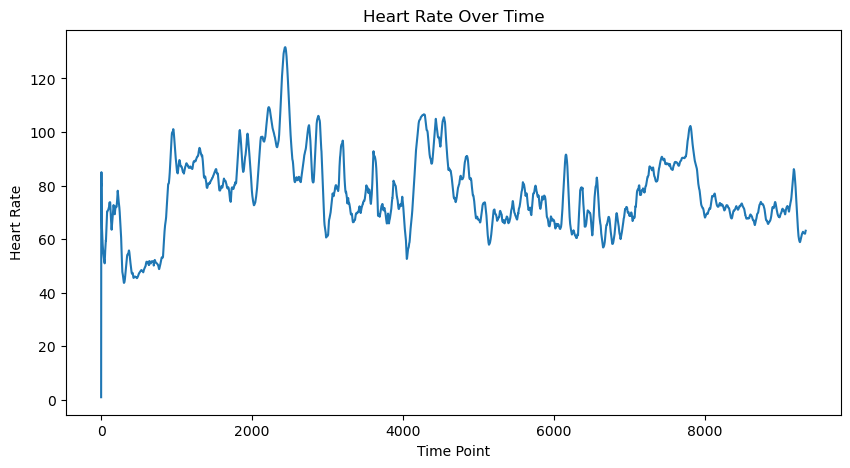

In [191]:
import pandas as pd
import numpy as np


# Replace with actual path after extraction
hr_data = pd.read_csv('C:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/S1/HR.csv')
# Create a simple sequential time axis
time_axis = np.arange(len(hr_data))  
# Analyze the data
print(hr_data.head())
print(hr_data.describe())

# Visualization
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(time_axis, hr_data)
plt.title('Heart Rate Over Time')
plt.xlabel('Time Point')
plt.ylabel('Heart Rate')
plt.show()

In [181]:
import pickle
import pandas as pd

# Load the DataFrame from the pickle file
df = pd.read_pickle('C:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/S1/S1.pkl')

# Now you can work with your DataFrame
print(df)

{'rpeaks': array([    240,    1174,    2128, ..., 6447292, 6447748, 6448224],
      shape=(11431,), dtype=int32), 'signal': {'chest': {'ACC': array([[ 0.85640001, -0.06779999, -0.36559999],
       [ 0.8556    , -0.06900001, -0.3646    ],
       [ 0.852     , -0.07020003, -0.3642    ],
       ...,
       [ 0.88759995, -0.1038    , -0.27920002],
       [ 0.88619995, -0.10159999, -0.27819997],
       [ 0.88680005, -0.10140002, -0.27380002]], shape=(6448400, 3)), 'ECG': array([[0.01560974],
       [0.01812744],
       [0.01753235],
       ...,
       [0.21368408],
       [0.21556091],
       [0.21702576]], shape=(6448400, 1)), 'EMG': array([[-1.5],
       [-1.5],
       [-1.5],
       ...,
       [-1.5],
       [-1.5],
       [-1.5]], shape=(6448400, 1)), 'EDA': array([[0.],
       [0.],
       [0.],
       ...,
       [0.],
       [0.],
       [0.]], shape=(6448400, 1)), 'Temp': array([[-273.15],
       [-273.15],
       [-273.15],
       ...,
       [-273.15],
       [-273.15],
       [-

In [182]:
def load_e4_zip_data(zip_path):
    """Extract and load data from E4 zip file"""
    e4_data = {}
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # List all files in the zip
        file_list = zip_ref.namelist()
        print(f"Files in E4 zip: {file_list}")
        
        # Extract each CSV file
        for file_name in file_list:
            if file_name.endswith('.csv'):
                signal_type = file_name.split('/')[-1].split('.')[0]
                
                with zip_ref.open(file_name) as f:
                    # The first row usually contains the sampling rate
                    content = f.read().decode('utf-8').splitlines()
                    if len(content) > 1:
                        sampling_rate = float(content[0].strip())
                        signal_data = np.array([float(x) for x in content[1:] if x.strip()])
                        
                        e4_data[signal_type] = {
                            'data': signal_data,
                            'sampling_rate': sampling_rate
                        }
    
    return e4_data

In [183]:
def visualize_ppg_data(data, subject_id):
    """Visualize the PPG data and extracted heart rates"""
    if 'ppg' not in data:
        print("No PPG data available for visualization")
        return
    
    # Create figure
    plt.figure(figsize=(15, 10))
    
    # Plot a section of raw PPG signal
    plt.subplot(3, 1, 1)
    sample_duration = 10  # seconds
    samples_to_plot = int(sample_duration * data['ppg_sampling_rate'])
    time_axis = np.arange(samples_to_plot) / data['ppg_sampling_rate']
    plt.plot(time_axis, data['ppg'][:samples_to_plot])
    plt.title(f'Raw PPG Signal - Subject {subject_id} (First {sample_duration} seconds)')
    plt.xlabel('Time (s)')
    plt.ylabel('Amplitude')
    
    # Extract and plot heart rate
    heart_rates, timestamps = extract_heart_rate_from_ppg(data['ppg'], data['ppg_sampling_rate'])
    
    plt.subplot(3, 1, 2)
    plt.plot(timestamps / 60, heart_rates)  # Convert timestamps to minutes
    plt.title(f'Extracted Heart Rate - Subject {subject_id}')
    plt.xlabel('Time (min)')
    plt.ylabel('Heart Rate (BPM)')
    plt.grid(True)
    
    # Plot heart rate histogram
    plt.subplot(3, 1, 3)
    plt.hist(heart_rates, bins=30, alpha=0.7)
    plt.axvline(np.mean(heart_rates), color='red', linestyle='--', 
               label=f'Mean: {np.mean(heart_rates):.1f} BPM')
    plt.axvline(np.median(heart_rates), color='green', linestyle='--', 
               label=f'Median: {np.median(heart_rates):.1f} BPM')
    plt.title(f'Heart Rate Distribution - Subject {subject_id}')
    plt.xlabel('Heart Rate (BPM)')
    plt.ylabel('Frequency')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\nHeart Rate Statistics:")
    print(f"Mean: {np.mean(heart_rates):.1f} BPM")
    print(f"Median: {np.median(heart_rates):.1f} BPM")
    print(f"Min: {np.min(heart_rates):.1f} BPM")
    print(f"Max: {np.max(heart_rates):.1f} BPM")
    print(f"Standard Deviation: {np.std(heart_rates):.1f} BPM")
    
    return heart_rates, timestamps


In [184]:
def create_ground_truth_from_ppg(ppg_data, subject_id):
    """
    Create ground truth dataset for image validation using PPG-derived heart rates
    
    Parameters:
    -----------
    ppg_data : dict
        Dictionary with PPG data and other signals
    subject_id : str
        Subject identifier
        
    Returns:
    --------
    DataFrame
        DataFrame with ground truth data ready for evaluate_system_accuracy
    """
    # Extract heart rates from PPG
    heart_rates, timestamps = extract_heart_rate_from_ppg(
        ppg_data['ppg'], ppg_data['ppg_sampling_rate'])
    
    # Use demographics from questionnaire if available
    demographics = {}
    if 'questionnaire' in ppg_data and not ppg_data['questionnaire'].empty:
        quest_data = ppg_data['questionnaire']
        # Extract relevant demographic info if available in your dataset
        if 'age' in quest_data.columns:
            demographics['age'] = quest_data['age'].iloc[0]
        if 'gender' in quest_data.columns:
            demographics['is_male'] = quest_data['gender'].iloc[0] == 'male'
        if 'weight' in quest_data.columns:
            demographics['weight_kg'] = quest_data['weight'].iloc[0]
        if 'height' in quest_data.columns:
            demographics['height_cm'] = quest_data['height'].iloc[0]
    
    # Default values if not available
    age = demographics.get('age', 30)
    is_male = demographics.get('is_male', True)
    weight_kg = demographics.get('weight_kg', 70)
    height_cm = demographics.get('height_cm', 170)
    
    # Create ground truth dataset
    # Assuming each heart rate measurement could correspond to an image
    ground_truth = []
    
    for i, (hr, timestamp) in enumerate(zip(heart_rates, timestamps)):
        # Generate a mapping between PPG timestamps and image filenames
        # In real use, you'd match these with actual image timestamps
        filename = f"{subject_id}_frame_{i:04d}.jpg"
        
        # Estimate BP based on heart rate and demographics using your existing function
        sys_bp, dia_bp = estimate_bp(hr, age, weight_kg, height_cm, is_male)
        
        ground_truth.append({
            'file': filename,
            'known_hr': hr,
            'known_systolic': sys_bp,  # Using estimated BP as ground truth
            'known_diastolic': dia_bp,
            'timestamp': timestamp,
            'age': age,
            'weight_kg': weight_kg,
            'height_cm': height_cm,
            'is_male': is_male
        })
    
    return pd.DataFrame(ground_truth)

In [185]:
ppg_data = load_ppg_dalia_data(subject_id='S1', base_path='c:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/')
print("Available keys:", ppg_data.keys())

Loading questionnaire data from c:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/S1\S1_quest.csv
Loaded questionnaire data with 6 entries
Loading activity data from c:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/S1\S1_activity.csv
Loaded activity data with 18 entries
Skipping E4 data loading due to encoding issues
Loaded E4 data with 0 signals
Loading processed data from c:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/S1\S1.pkl
Successfully loaded processed data with pandas.read_pickle
Available keys: dict_keys(['subject_id', 'questionnaire', 'activity', 'e4', 'processed'])


In [186]:
def load_e4_zip_data(zip_path):
    """Extract and load data from E4 zip file"""
    e4_data = {}
    
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        # List all files in the zip
        file_list = zip_ref.namelist()
        print(f"Files in E4 zip: {file_list}")
        
        # Extract each CSV file
        for file_name in file_list:
            if file_name.endswith('.csv'):
                signal_type = file_name.split('/')[-1].split('.')[0]
                
                try:
                    with zip_ref.open(file_name) as f:
                        # Try different encodings to handle the file
                        encodings_to_try = ['utf-8', 'latin-1', 'iso-8859-1', 'cp1252']
                        
                        for encoding in encodings_to_try:
                            try:
                                # Read raw bytes and attempt to decode
                                raw_data = f.read()
                                content = raw_data.decode(encoding).splitlines()
                                break  # If successful, exit the encoding loop
                            except UnicodeDecodeError:
                                if encoding == encodings_to_try[-1]:
                                    print(f"  Could not decode {file_name} with any encoding, skipping")
                                    continue
                            except Exception as e:
                                print(f"  Error reading {file_name}: {str(e)}")
                                continue
                            
                        if len(content) > 1:
                            # Handle sampling rate (first line)
                            sampling_rate_line = content[0].strip()
                            # Some files might have comma-separated values on the first line
                            if ',' in sampling_rate_line:
                                sampling_rate = float(sampling_rate_line.split(',')[0])
                            else:
                                sampling_rate = float(sampling_rate_line)
                            
                            # Handle data lines (remaining lines)
                            signal_data = []
                            for line in content[1:]:
                                if line.strip():
                                    try:
                                        # Handle comma-separated values
                                        if ',' in line:
                                            # Take first value or process all values depending on signal type
                                            values = [float(val.strip()) for val in line.split(',') if val.strip()]
                                            if len(values) > 0:
                                                signal_data.append(values[0])  # Just take first value for now
                                        else:
                                            signal_data.append(float(line.strip()))
                                    except ValueError:
                                        # Skip lines that can't be converted to float
                                        continue
                            
                            e4_data[signal_type] = {
                                'data': np.array(signal_data) if signal_data else np.array([]),
                                'sampling_rate': sampling_rate
                            }
                except Exception as e:
                    print(f"Error processing {file_name}: {str(e)}")
                    # Continue with other files even if one fails
    
    return e4_data

In [187]:
import base64
import os

# Create a directory for your images
image_dir = "vitalSignsImages"
os.makedirs(image_dir, exist_ok=True)

# Your base64 string
base64_string = "..."

# Remove header if it exists (e.g., "data:image/jpeg;base64,")
if base64_string.startswith('data:image'):
    base64_string = base64_string.split(',')[1]

# Decode the base64 string
try:
    image_data = base64.b64decode(base64_string)
    
    # Save the image with a timestamp or subject ID in the filename
    timestamp = int(time.time())  # Current time in seconds
    image_path = os.path.join(image_dir, f"S1_t{timestamp}.jpg")  # Format compatible with timestamp matching
    
    with open(image_path, "wb") as f:
        f.write(image_data)
    
    print(f"Image saved to {image_path}")
except Exception as e:
    print(f"Error decoding base64 string: {e}")

# Now use this directory with the validation function
validation_results = validate_with_ppg_dalia(
    subject_id='S1', 
    base_path='c:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/',
    image_dir=image_dir,  # Use the directory where we saved the image
    save_results=True,
    generate_sample_images=False  # Set to False since we've added our own image
)

# Examine the results
if "results" in validation_results:
    print("Analysis completed successfully!")
    
    # Print heart rate results
    if "hr_metrics" in validation_results["results"]:
        print("\nHeart Rate Metrics:")
        for key, value in validation_results["results"]["hr_metrics"].items():
            print(f"  {key}: {value}")

Error decoding base64 string: name 'time' is not defined
Starting validation for subject S1
Loading questionnaire data from c:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/S1\S1_quest.csv
Loaded questionnaire data with 6 entries
Loading activity data from c:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/S1\S1_activity.csv
Loaded activity data with 18 entries
Skipping E4 data loading due to encoding issues
Loaded E4 data with 0 signals
Loading processed data from c:/Users/bchal/Downloads/ppg+dalia/data/PPG_FieldStudy/S1\S1.pkl
Successfully loaded processed data with pandas.read_pickle
Available keys in ppg_data: ['subject_id', 'questionnaire', 'activity', 'e4', 'processed']


ValueError: Could not find PPG signal or sampling rate in the loaded data. Available keys: ['subject_id', 'questionnaire', 'activity', 'e4', 'processed']